In [1]:
import pandas as pd
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("../data/train.csv")

In [2]:
df.groupby("transaction_id")["placement_score"].nunique().describe()

count    308.000000
mean       4.412338
std        1.532103
min        2.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        9.000000
Name: placement_score, dtype: float64

In [3]:
df.groupby("product_subcategory")["placement_score"].nunique().describe()

count    49.000000
mean     25.387755
std       6.254386
min       7.000000
25%      23.000000
50%      25.000000
75%      29.000000
max      37.000000
Name: placement_score, dtype: float64

In [4]:
df.groupby("transaction_id")["placement_score"].nunique().describe()

count    308.000000
mean       4.412338
std        1.532103
min        2.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        9.000000
Name: placement_score, dtype: float64

In [5]:
df.groupby("product_subcategory")["placement_score"].nunique().describe()

count    49.000000
mean     25.387755
std       6.254386
min       7.000000
25%      23.000000
50%      25.000000
75%      29.000000
max      37.000000
Name: placement_score, dtype: float64

In [6]:
df[
    [
        "transaction_id",
        "product_subcategory",
        "quantity",
        "total_amount",
        "placement_score"
    ]
].head(30)

,transaction_id,product_subcategory,quantity,total_amount,placement_score
0,TXN_000001,Cheese,4,27.72,73.1
1,TXN_000001,Chicken,1,5.41,37.6
2,TXN_000001,Crackers,3,11.40,74.4
3,TXN_000001,Toothpaste,1,2.91,40.8
4,TXN_000002,Soap,1,1.87,71.9
5,TXN_000002,Shampoo,1,6.93,82.5
6,TXN_000002,Toothpaste,1,4.36,55.5
7,TXN_000002,Crackers,2,4.28,66.6
8,TXN_000002,Cheese,2,9.36,73.2
9,TXN_000003,Soap,1,1.37,67.7


In [7]:
basket_size = df.groupby("transaction_id").size()

basket_value = df.groupby("transaction_id")["total_amount"].sum()

basket_quantity = df.groupby("transaction_id")["quantity"].sum()

In [8]:
df["basket_size"] = df["transaction_id"].map(basket_size)

df["basket_value"] = df["transaction_id"].map(basket_value)

df["product_basket_share"] = (
    df["total_amount"] / df["basket_value"]
)

df["quantity_share"] = (
    df["quantity"] / df["transaction_id"].map(basket_quantity)
)

In [9]:
df[
    [
        "transaction_id",
        "product_subcategory",
        "quantity",
        "total_amount",
        "basket_size",
        "basket_value",
        "product_basket_share",
        "quantity_share",
        "placement_score"
    ]
].head(10)

,transaction_id,product_subcategory,quantity,total_amount,basket_size,basket_value,product_basket_share,quantity_share,placement_score
0,TXN_000001,Cheese,4,27.72,4,47.44,0.584317,0.444444,73.1
1,TXN_000001,Chicken,1,5.41,4,47.44,0.114039,0.111111,37.6
2,TXN_000001,Crackers,3,11.40,4,47.44,0.240304,0.333333,74.4
3,TXN_000001,Toothpaste,1,2.91,4,47.44,0.061341,0.111111,40.8
4,TXN_000002,Soap,1,1.87,5,26.80,0.069776,0.142857,71.9
5,TXN_000002,Shampoo,1,6.93,5,26.80,0.258582,0.142857,82.5
6,TXN_000002,Toothpaste,1,4.36,5,26.80,0.162687,0.142857,55.5
7,TXN_000002,Crackers,2,4.28,5,26.80,0.159701,0.285714,66.6
8,TXN_000002,Cheese,2,9.36,5,26.80,0.349254,0.285714,73.2
9,TXN_000003,Soap,1,1.37,6,51.89,0.026402,0.090909,67.7


In [10]:
product_frequency = (
    df.groupby("product_subcategory")["transaction_id"]
    .nunique()
)

product_customer_count = (
    df.groupby("product_subcategory")["customer_id"]
    .nunique()
)

product_avg_quantity = (
    df.groupby("product_subcategory")["quantity"]
    .mean()
)

product_avg_amount = (
    df.groupby("product_subcategory")["total_amount"]
    .mean()
)

In [11]:
df["product_frequency"] = (
    df["product_subcategory"].map(product_frequency)
)

df["product_customer_count"] = (
    df["product_subcategory"].map(product_customer_count)
)

df["product_avg_quantity"] = (
    df["product_subcategory"].map(product_avg_quantity)
)

df["product_avg_amount"] = (
    df["product_subcategory"].map(product_avg_amount)
)

In [12]:
df[
    [
        "product_subcategory",
        "product_frequency",
        "product_customer_count",
        "product_avg_quantity",
        "product_avg_amount"
    ]
].drop_duplicates().head(20)

,product_subcategory,product_frequency,product_customer_count,product_avg_quantity,product_avg_amount
0,Cheese,29,29,1.517241,8.996552
1,Chicken,29,28,1.586207,13.634828
2,Crackers,32,32,2.250000,7.091875
3,Toothpaste,24,23,1.625000,5.616667
4,Soap,41,38,1.926829,4.694878
5,Shampoo,40,36,2.125000,17.313500
11,Onions,38,35,1.763158,3.175526
12,Pasta,41,40,1.829268,4.297561
13,Beef,39,37,1.743590,21.579231
14,Cereals,29,27,1.827586,8.675862


In [14]:
product_max_lift = {}

for product, associations in association_features.items():
    product_max_lift[product] = max(
        a["lift"] for a in associations
    )

df["max_lift"] = (
    df["product_subcategory"]
    .map(product_max_lift)
    .fillna(0)
)

NameError: name 'association_features' is not defined

In [15]:
basket = (
    df.groupby("transaction_id")["product_subcategory"]
    .apply(list)
)

In [16]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()

basket_encoded = te.fit(basket).transform(basket)

basket_df = pd.DataFrame(
    basket_encoded,
    columns=te.columns_
)

In [17]:
frequent_itemsets = apriori(
    basket_df,
    min_support=0.05,
    use_colnames=True
)

In [18]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

In [19]:
pair_rules = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1)
].copy()

In [20]:
association_features = {}

for _, row in pair_rules.iterrows():
    for product in row["antecedents"]:
        association_features.setdefault(product, []).append({
            "partner": list(row["consequents"])[0],
            "lift": row["lift"],
            "confidence": row["confidence"],
            "support": row["support"]
        })

    for product in row["consequents"]:
        association_features.setdefault(product, []).append({
            "partner": list(row["antecedents"])[0],
            "lift": row["lift"],
            "confidence": row["confidence"],
            "support": row["support"]
        })

In [21]:
product_max_lift = {}

for product, associations in association_features.items():
    product_max_lift[product] = max(
        a["lift"] for a in associations
    )

df["max_lift"] = (
    df["product_subcategory"]
    .map(product_max_lift)
    .fillna(0)
)

In [22]:
product_avg_lift = {}

for product, associations in association_features.items():
    product_avg_lift[product] = np.mean(
        [a["lift"] for a in associations]
    )

df["avg_lift"] = (
    df["product_subcategory"]
    .map(product_avg_lift)
    .fillna(0)
)

In [23]:
product_max_confidence = {}

for product, associations in association_features.items():
    product_max_confidence[product] = max(
        a["confidence"] for a in associations
    )

df["max_confidence"] = (
    df["product_subcategory"]
    .map(product_max_confidence)
    .fillna(0)
)

In [24]:
product_association_count = {
    product: len(associations)
    for product, associations in association_features.items()
}

df["association_count"] = (
    df["product_subcategory"]
    .map(product_association_count)
    .fillna(0)
)

In [25]:
df[["product_category", "product_subcategory"]].drop_duplicates()

,product_category,product_subcategory
0,Dairy,Cheese
1,Meat,Chicken
2,Snacks,Crackers
3,Personal_Care,Toothpaste
4,Personal_Care,Soap
5,Personal_Care,Shampoo
11,Produce,Onions
12,Pantry,Pasta
13,Meat,Beef
14,Pantry,Cereals


In [27]:
pair_lift = {}

for _, row in pair_rules.iterrows():
    product_a = list(row["antecedents"])[0]
    product_b = list(row["consequents"])[0]

    pair = tuple(sorted([product_a, product_b]))
    pair_lift[pair] = row["lift"]

In [29]:
def get_basket_association_features(row):
    transaction_products = set(
        df.loc[
            df["transaction_id"] == row["transaction_id"],
            "product_subcategory"
        ]
    )

    current_product = row["product_subcategory"]

    lifts = []

    for other_product in transaction_products:
        if other_product == current_product:
            continue

        pair = tuple(sorted([current_product, other_product]))

        if pair in pair_lift:
            lifts.append(pair_lift[pair])

    if len(lifts) == 0:
        return pd.Series({
            "basket_partner_count": 0,
            "basket_avg_partner_lift": 0,
            "basket_max_partner_lift": 0
        })

    return pd.Series({
        "basket_partner_count": len(lifts),
        "basket_avg_partner_lift": np.mean(lifts),
        "basket_max_partner_lift": max(lifts)
    })

In [30]:
basket_association_features = df.apply(
    get_basket_association_features,
    axis=1
)

df = pd.concat(
    [df, basket_association_features],
    axis=1
)

In [31]:
df[
    [
        "basket_partner_count",
        "basket_avg_partner_lift",
        "basket_max_partner_lift"
    ]
].head(10)

,basket_partner_count,basket_avg_partner_lift,basket_max_partner_lift
0,1.0,7.965517,7.965517
1,0.0,0.000000,0.000000
2,1.0,7.965517,7.965517
3,0.0,0.000000,0.000000
4,1.0,6.197561,6.197561
5,1.0,6.197561,6.197561
6,0.0,0.000000,0.000000
7,1.0,7.965517,7.965517
8,1.0,7.965517,7.965517
9,1.0,6.197561,6.197561


In [32]:
feature_columns = [
    "quantity",
    "unit_price",
    "total_amount",
    "basket_size",
    "basket_value",
    "product_basket_share",
    "quantity_share",
    "product_frequency",
    "product_customer_count",
    "product_avg_quantity",
    "product_avg_amount",
    "max_lift",
    "avg_lift",
    "max_confidence",
    "association_count",
    "basket_partner_count",
    "basket_avg_partner_lift",
    "basket_max_partner_lift"
]

X = df[feature_columns]
y = df["placement_score"]

In [33]:
print(X.shape)
print(y.shape)

(1500, 18)
(1500,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)

In [37]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y_val, lr_pred),
        mean_absolute_error(y_val, rf_pred),
        mean_absolute_error(y_val, gb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, lr_pred)),
        np.sqrt(mean_squared_error(y_val, rf_pred)),
        np.sqrt(mean_squared_error(y_val, gb_pred))
    ],
    "R2": [
        r2_score(y_val, lr_pred),
        r2_score(y_val, rf_pred),
        r2_score(y_val, gb_pred)
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
2,Gradient Boosting,9.033482,11.437059,0.653545
0,Linear Regression,9.199916,11.813364,0.630372
1,Random Forest,9.469897,12.000835,0.618547


In [39]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": gb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
16,basket_avg_partner_lift,0.399723
3,basket_size,0.147879
17,basket_max_partner_lift,0.083800
15,basket_partner_count,0.057443
2,total_amount,0.054569
1,unit_price,0.050679
10,product_avg_amount,0.044921
4,basket_value,0.041156
0,quantity,0.029966
9,product_avg_quantity,0.026807


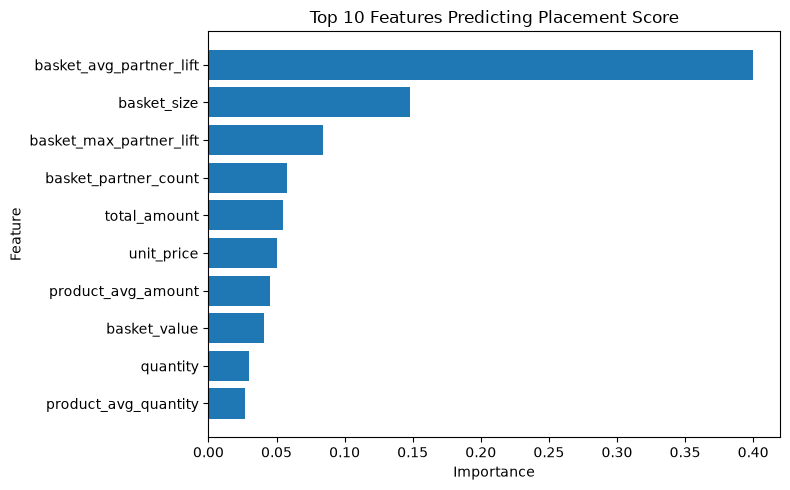

In [40]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Predicting Placement Score")
plt.tight_layout()
plt.show()


In [41]:
test_df = pd.read_csv("../data/test.csv")

test_df.head()

,transaction_id,customer_id,product_category,product_subcategory,quantity,unit_price,total_amount
0,TEST_TXN_0001,CUST_0346,Bakery,Bread,1,2.61,2.61
1,TEST_TXN_0001,CUST_0346,Dairy,Butter,1,5.67,5.67
2,TEST_TXN_0001,CUST_0346,Snacks,Nuts,1,11.58,11.58
3,TEST_TXN_0001,CUST_0346,Unknown,Beer,3,4.54,13.62
4,TEST_TXN_0005,CUST_0391,Snacks,Cookies,1,5.10,5.10


In [45]:
test_basket_size = (
    test_df.groupby("transaction_id").size()
)

test_basket_value = (
    test_df.groupby("transaction_id")["total_amount"].sum()
)

test_basket_quantity = (
    test_df.groupby("transaction_id")["quantity"].sum()
)

In [46]:
test_df["basket_size"] = (
    test_df["transaction_id"].map(test_basket_size)
)

test_df["basket_value"] = (
    test_df["transaction_id"].map(test_basket_value)
)

test_df["product_basket_share"] = (
    test_df["total_amount"] / test_df["basket_value"]
)

test_df["quantity_share"] = (
    test_df["quantity"] /
    test_df["transaction_id"].map(test_basket_quantity)
)

In [47]:
test_df["product_frequency"] = (
    test_df["product_subcategory"].map(product_frequency)
)

test_df["product_customer_count"] = (
    test_df["product_subcategory"].map(product_customer_count)
)

test_df["product_avg_quantity"] = (
    test_df["product_subcategory"].map(product_avg_quantity)
)

test_df["product_avg_amount"] = (
    test_df["product_subcategory"].map(product_avg_amount)
)

In [48]:
test_df["max_lift"] = (
    test_df["product_subcategory"]
    .map(product_max_lift)
    .fillna(0)
)

test_df["avg_lift"] = (
    test_df["product_subcategory"]
    .map(product_avg_lift)
    .fillna(0)
)

test_df["max_confidence"] = (
    test_df["product_subcategory"]
    .map(product_max_confidence)
    .fillna(0)
)

test_df["association_count"] = (
    test_df["product_subcategory"]
    .map(product_association_count)
    .fillna(0)
)

In [49]:
test_pair_lift = pair_lift

In [50]:
def get_test_basket_association_features(row):
    transaction_products = set(
        test_df.loc[
            test_df["transaction_id"] == row["transaction_id"],
            "product_subcategory"
        ]
    )

    current_product = row["product_subcategory"]

    lifts = []

    for other_product in transaction_products:
        if other_product == current_product:
            continue

        pair = tuple(sorted([current_product, other_product]))

        if pair in test_pair_lift:
            lifts.append(test_pair_lift[pair])

    if len(lifts) == 0:
        return pd.Series({
            "basket_partner_count": 0,
            "basket_avg_partner_lift": 0,
            "basket_max_partner_lift": 0
        })

    return pd.Series({
        "basket_partner_count": len(lifts),
        "basket_avg_partner_lift": np.mean(lifts),
        "basket_max_partner_lift": max(lifts)
    })

In [51]:
test_basket_association_features = test_df.apply(
    get_test_basket_association_features,
    axis=1
)

test_df = pd.concat(
    [test_df, test_basket_association_features],
    axis=1
)

In [52]:
test_df[feature_columns].head()

,quantity,unit_price,total_amount,basket_size,basket_value,product_basket_share,quantity_share,product_frequency,product_customer_count,product_avg_quantity,product_avg_amount,max_lift,avg_lift,max_confidence,association_count,basket_partner_count,basket_avg_partner_lift,basket_max_partner_lift
0,1,2.61,2.61,4,33.48,0.077957,0.166667,30,29,1.700000,5.267000,8.213333,8.213333,0.800000,2.0,1.0,8.213333,8.213333
1,1,5.67,5.67,4,33.48,0.169355,0.166667,30,29,1.733333,8.239333,8.213333,8.213333,0.800000,2.0,1.0,8.213333,8.213333
2,1,11.58,11.58,4,33.48,0.345878,0.166667,20,18,1.850000,14.189500,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3,3,4.54,13.62,4,33.48,0.406810,0.500000,10,10,2.000000,11.646000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
4,1,5.10,5.10,5,24.60,0.207317,0.166667,36,33,1.722222,7.068889,6.740741,6.092593,0.787879,4.0,2.0,6.092593,6.740741


In [53]:
test_df[feature_columns].isnull().sum()

quantity                   0
unit_price                 0
total_amount               0
basket_size                0
basket_value               0
product_basket_share       0
quantity_share             0
product_frequency          0
product_customer_count     0
product_avg_quantity       0
product_avg_amount         0
max_lift                   0
avg_lift                   0
max_confidence             0
association_count          0
basket_partner_count       0
basket_avg_partner_lift    0
basket_max_partner_lift    0
dtype: int64

In [54]:
final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [55]:
final_model.fit(
    df[feature_columns],
    df["placement_score"]
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [56]:
test_predictions = final_model.predict(
    test_df[feature_columns]
)

In [57]:
test_predictions[:10]

array([84.35948383, 86.59741858, 58.72399727, 75.71334518, 89.31622012,
       85.83790464, 78.7709242 , 60.30321992, 68.74838057, 91.32976596])

In [58]:
test_predictions = np.clip(
    test_predictions,
    0,
    100
)

In [59]:
pd.Series(test_predictions).describe()

count    200.000000
mean      81.009742
std       12.669460
min       38.213538
25%       73.235543
50%       84.272806
75%       91.258241
max      100.000000
dtype: float64

In [60]:
sample_submission = pd.read_csv(
    "../data/sample_submission.csv"
)

sample_submission

,transaction_id,product_subcategory,placement_score
0,TEST_TXN_0001,Bread,50.0
1,TEST_TXN_0001,Butter,50.0
2,TEST_TXN_0001,Nuts,50.0
3,TEST_TXN_0001,Beer,50.0
4,TEST_TXN_0005,Cookies,50.0


In [61]:
sample_submission.columns

Index(['transaction_id', 'product_subcategory', 'placement_score'], dtype='str')

In [62]:
feature_importance.head(10)

,feature,importance
16,basket_avg_partner_lift,0.399723
3,basket_size,0.147879
17,basket_max_partner_lift,0.083800
15,basket_partner_count,0.057443
2,total_amount,0.054569
1,unit_price,0.050679
10,product_avg_amount,0.044921
4,basket_value,0.041156
0,quantity,0.029966
9,product_avg_quantity,0.026807


In [63]:
sample_submission

,transaction_id,product_subcategory,placement_score
0,TEST_TXN_0001,Bread,50.0
1,TEST_TXN_0001,Butter,50.0
2,TEST_TXN_0001,Nuts,50.0
3,TEST_TXN_0001,Beer,50.0
4,TEST_TXN_0005,Cookies,50.0


In [64]:
submission = pd.DataFrame({
    "transaction_id": test_df["transaction_id"],
    "product_subcategory": test_df["product_subcategory"],
    "placement_score": test_predictions
})

In [65]:
submission = pd.DataFrame({
    "transaction_id": test_df["transaction_id"],
    "product_subcategory": test_df["product_subcategory"],
    "placement_score": test_predictions
})

In [66]:
submission.head(10)

,transaction_id,product_subcategory,placement_score
0,TEST_TXN_0001,Bread,84.359484
1,TEST_TXN_0001,Butter,86.597419
2,TEST_TXN_0001,Nuts,58.723997
3,TEST_TXN_0001,Beer,75.713345
4,TEST_TXN_0005,Cookies,89.316220
5,TEST_TXN_0005,Ice_Cream,85.837905
6,TEST_TXN_0005,Juice,78.770924
7,TEST_TXN_0005,Frozen_Meals,60.303220
8,TEST_TXN_0005,Chips,68.748381
9,TEST_TXN_0010,Butter,91.329766


In [67]:
print(submission.shape)
print(submission.columns.tolist())

(200, 3)
['transaction_id', 'product_subcategory', 'placement_score']


In [68]:
submission["placement_score"].describe()

count    200.000000
mean      81.009742
std       12.669460
min       38.213538
25%       73.235543
50%       84.272806
75%       91.258241
max      100.000000
Name: placement_score, dtype: float64

In [69]:
print("Submission columns:")
print(submission.columns.tolist())

print("\nSample columns:")
print(sample_submission.columns.tolist())

Submission columns:
['transaction_id', 'product_subcategory', 'placement_score']

Sample columns:
['transaction_id', 'product_subcategory', 'placement_score']


In [71]:
submission.to_csv(
    "../outputs/submission.csv",
    index=False
)

In [72]:
pd.read_csv("../outputs/submission.csv").head(10)

,transaction_id,product_subcategory,placement_score
0,TEST_TXN_0001,Bread,84.359484
1,TEST_TXN_0001,Butter,86.597419
2,TEST_TXN_0001,Nuts,58.723997
3,TEST_TXN_0001,Beer,75.713345
4,TEST_TXN_0005,Cookies,89.316220
5,TEST_TXN_0005,Ice_Cream,85.837905
6,TEST_TXN_0005,Juice,78.770924
7,TEST_TXN_0005,Frozen_Meals,60.303220
8,TEST_TXN_0005,Chips,68.748381
9,TEST_TXN_0010,Butter,91.329766


In [73]:
assert len(test_predictions) == len(test_df)
assert len(submission) == len(test_df)
assert submission["placement_score"].between(0, 100).all()

In [74]:
submission.sort_values(
    "placement_score",
    ascending=False
).head(10)

,transaction_id,product_subcategory,placement_score
165,TEST_TXN_0166,Chips,100.000000
87,TEST_TXN_0088,Chicken,100.000000
90,TEST_TXN_0088,Onions,98.645031
83,TEST_TXN_0083,Chicken,98.315194
169,TEST_TXN_0166,Cream,97.539409
188,TEST_TXN_0186,Soda,97.217299
40,TEST_TXN_0037,Lettuce,96.999922
49,TEST_TXN_0047,Butter,96.942474
187,TEST_TXN_0186,Chips,95.792765
180,TEST_TXN_0180,Bagels,95.640308
